## Plot Time Series

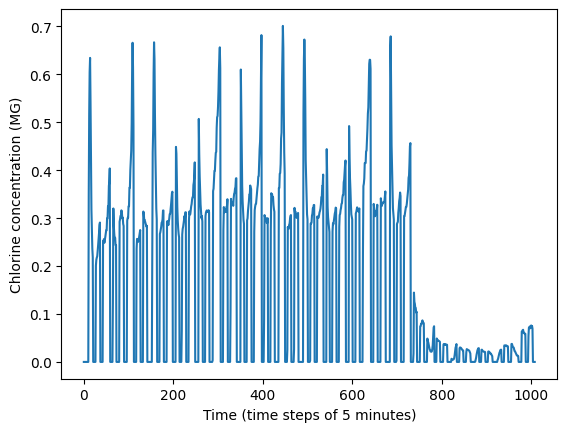

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

def plot_time_series(df, node):
    """ 
    Plots the time series of chlorine concentration for a specific node.
    
    Parameters:
    - df : The DataFrame containing the data (pd.DataFrame)
    - node : The node identifier for which to plot the chlorine concentration (string)
    
    """

    column_name_cl = f"bulk_species_node [MG] at Chlorine @ {node}"
    if column_name_cl in df.columns:
        df[column_name_cl].plot()
        # add labels 
        plt.xlabel("Time (time steps of 5 minutes)")
        plt.ylabel("Chlorine concentration (MG)")
        plt.savefig("chlo_anomaly.pdf")
    else:
        print(f"Column {column_name_cl} not found in DataFrame.")

df = pd.read_csv(".\\data_net1\\scada_data_conta_22_test_3.csv")    
node = "11"
plot_time_series(df, node)

## Adding Gaussian Noise and Blank Values

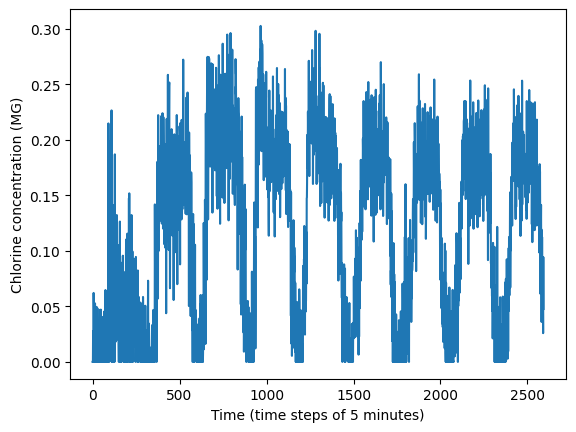

In [ ]:
import numpy as np
import pandas as pd

def gaussian_noise(x,mu,std):
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    x_noisy = np.clip(x_noisy, a_min=0, a_max=None) # set negative values to 0
    return x_noisy 

df_path = ".\\data_cy\\scada_data_clean_1.csv"
df = pd.read_csv(df_path)

node_id = "dist1363"
column_name = f"bulk_species_node [MG] at Chlorine @ {node_id}"
x_noisy = gaussian_noise(df[column_name].values, mu=0.0, std=0.03)
df_copy = df.copy()
df_copy[column_name] = x_noisy

plot_time_series(df_copy, node_id)
df_copy.to_csv(f".\\data_compet\\scada_data_test_6_noisy.csv", index=False)
df = df_copy

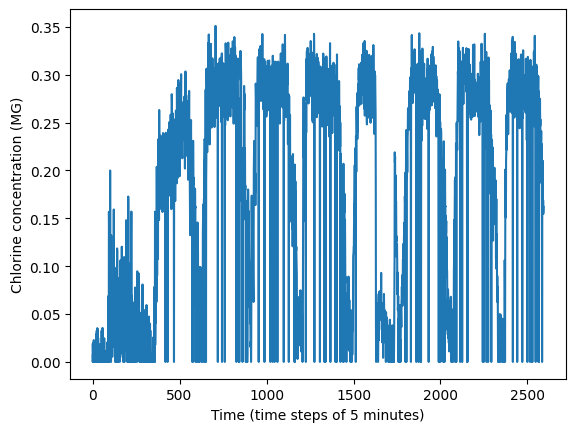

In [ ]:
import numpy as np

def sensor_defect(x, pourcentage): 
    x_noised = x.copy()
    num_defects = int(pourcentage * len(x))
    defect_indices = np.random.choice(len(x), num_defects, replace=False)
    x_noised[defect_indices] = 0
    return x_noised

node_id = "dist1363"
column_name = f"bulk_species_node [MG] at Chlorine @ {node_id}"
df = pd.read_csv(".\\data_cy\\scada_data_test_6_noisy.csv")

x_defected = sensor_defect(df[column_name].values, 0.02)
df_defected = df.copy()
df_defected[column_name] = x_defected

plot_time_series(df_defected, node_id)
df_defected.to_csv(f".\\data_cy\\scada_data_test_6_noisy.csv", index=False)